In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
annual_all = pd.read_parquet("data/annual_distribution_mickey.parquet")
quarterly_all = pd.read_parquet("data/quarterly_distribution_mickey.parquet")
monthly_all = pd.read_parquet("data/monthly_distribution_mickey.parquet")

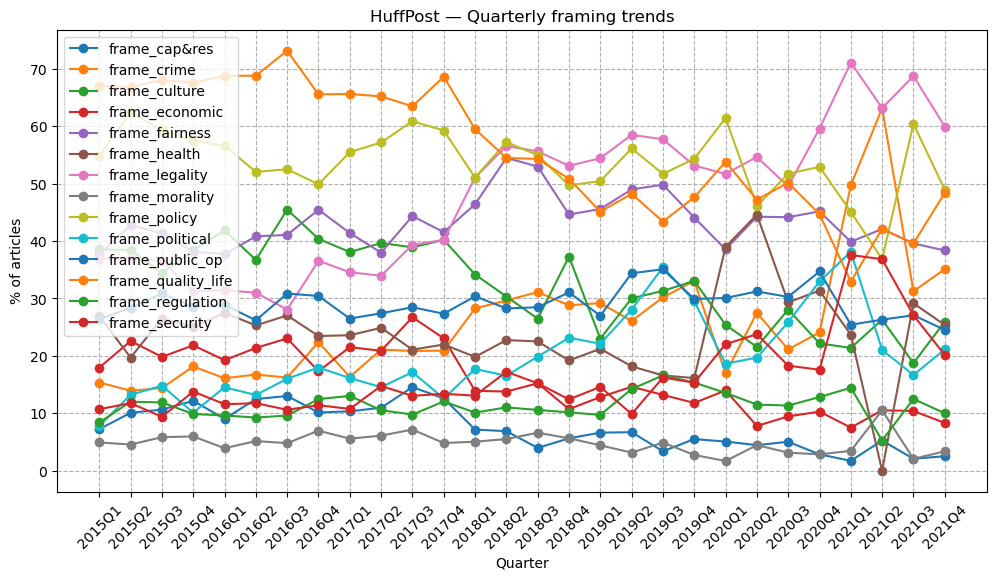

In [3]:
# Multi line plot with one outlet over time
outlet = "HuffPost"

quarterly = quarterly_all.loc[outlet]

plt.figure(figsize=(12,6))
for frame in quarterly.columns:
    plt.plot(quarterly.index, quarterly[frame], label=frame, marker="o")

plt.title(f"{outlet} — Quarterly framing trends")
plt.ylabel("% of articles")
plt.xlabel("Quarter")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle="--")
plt.show()

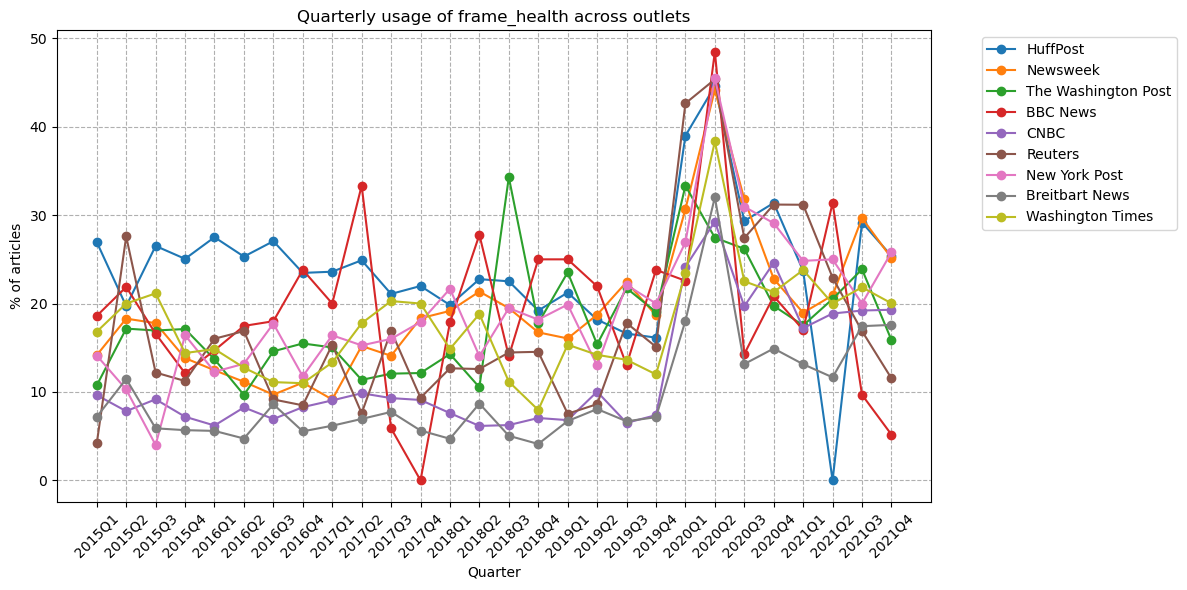

In [4]:
# Multi line plot with one frame over time
frame = "frame_health"

plt.figure(figsize=(12,6))
for outlet in quarterly_all.index.get_level_values(0).unique():
    quarterly = quarterly_all.loc[outlet]
    plt.plot(quarterly.index,quarterly[frame],label=outlet,marker="o")

plt.title(f"Quarterly usage of {frame} across outlets")
plt.ylabel("% of articles")
plt.xlabel("Quarter")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.show()

In [5]:
# Melt to long format and compute biggest change each quarter
quarterly_long = (quarterly_all.reset_index().melt(id_vars=["outlet", "quarter"],var_name="frame",value_name="pct"))


quarterly_long["delta_q"] = (quarterly_long.groupby(["outlet", "frame"])["pct"].diff())

In [9]:
# Show biggest changes per outlet
outlet = "HuffPost"

big_moves = (quarterly_long[quarterly_long["outlet"] == outlet].dropna(subset=["delta_q"]).sort_values("delta_q", ascending=False))

big_moves

,outlet,quarter,frame,pct,delta_q
1286,HuffPost,2021Q3,frame_health,29.166667,29.166667
276,HuffPost,2021Q1,frame_crime,49.710983,25.622235
2042,HuffPost,2021Q3,frame_policy,60.416667,23.574561
1280,HuffPost,2020Q1,frame_health,38.983051,22.841319
3300,HuffPost,2021Q1,frame_security,37.572254,19.981129
277,HuffPost,2021Q2,frame_crime,63.157895,13.446912
1536,HuffPost,2021Q1,frame_legality,71.098266,11.510310
1524,HuffPost,2018Q1,frame_legality,51.054852,10.840375
519,HuffPost,2018Q4,frame_culture,37.288136,10.798069
273,HuffPost,2020Q2,frame_crime,27.509294,10.560141


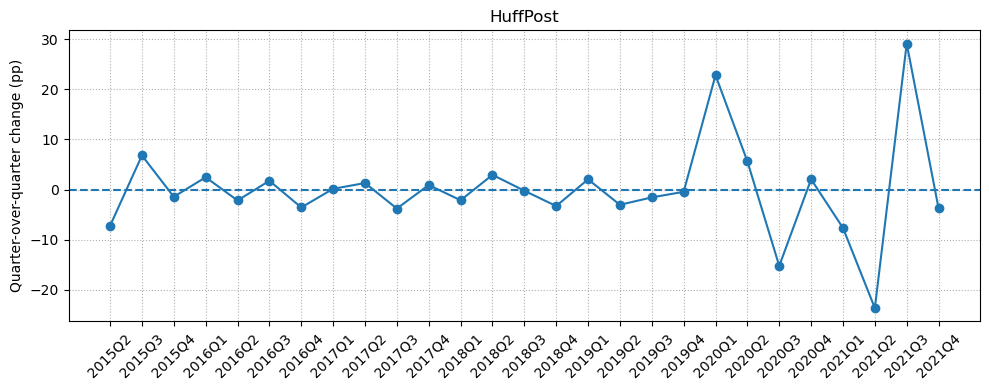

In [10]:
#Visualize framing shift for single frame/outlet

outlet = "HuffPost"
frame = "frame_health"

subset = quarterly_long[(quarterly_long["outlet"] == outlet) & (quarterly_long["frame"] == frame)].dropna(subset=["delta_q"])

plt.figure(figsize=(10,4))
plt.plot(subset["quarter"], subset["delta_q"], marker="o")
plt.axhline(0, linestyle="--")
plt.xticks(rotation=45)
plt.ylabel("Quarter-over-quarter change (pp)")
plt.title(f"{outlet}")
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()


In [11]:
# Compute mean/standard deviation across outlets for each quarter/frame
stats = (quarterly_long.groupby(["quarter", "frame"])["delta_q"].agg(mean_delta="mean", std_delta="std").reset_index())

# merge back
q_with_stats = quarterly_long.merge(stats,on=["quarter", "frame"],how="left")

# z-score of how unusual each outlet's change is
q_with_stats["delta_z"] = ((q_with_stats["delta_q"] - q_with_stats["mean_delta"]) / q_with_stats["std_delta"])

In [13]:
# Comapre events wehere an outlets shift in frame is unusally large compared to peers (Z score over 2)

big_outlier_moves = q_with_stats[q_with_stats["delta_z"].abs() >= 2].sort_values("delta_z", ascending=False)

big_outlier_moves

,outlet,quarter,frame,pct,delta_q,mean_delta,std_delta,delta_z
146,Reuters,2016Q3,frame_cap&res,34.640523,15.160003,1.663487,5.142433,2.624539
599,BBC News,2017Q4,frame_culture,42.857143,31.092437,3.588181,10.499608,2.619551
610,BBC News,2020Q3,frame_culture,57.142857,29.870130,5.547515,9.578398,2.539320
606,BBC News,2019Q3,frame_culture,37.826087,13.435843,1.139517,4.868939,2.525463
71,The Washington Post,2018Q4,frame_cap&res,37.777778,23.492063,2.726308,8.228195,2.523731
...,...,...,...,...,...,...,...,...
2101,BBC News,2015Q2,frame_policy,57.812500,-18.931686,0.536119,7.670988,-2.537849
2107,BBC News,2016Q4,frame_policy,42.857143,-25.142857,-2.016749,9.030548,-2.560875
2067,Newsweek,2020Q4,frame_policy,58.731618,-4.449210,0.505858,1.931192,-2.565808
2845,The Washington Post,2019Q2,frame_quality_life,23.076923,-29.864253,-1.758807,10.940009,-2.569051


Index(['frame_cap&res', 'frame_crime', 'frame_culture', 'frame_economic',
       'frame_fairness', 'frame_health', 'frame_legality', 'frame_morality',
       'frame_policy', 'frame_political', 'frame_public_op',
       'frame_quality_life', 'frame_regulation', 'frame_security'],
      dtype='object')

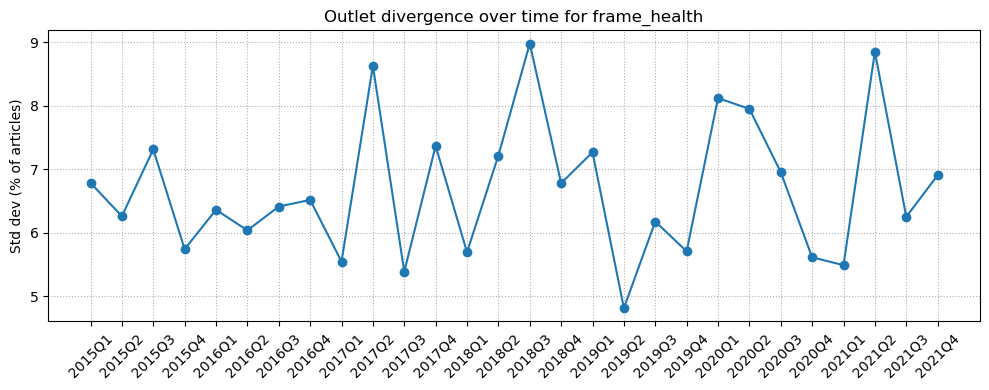

In [19]:
# Compate how much divergence at each event

# std of each frame across outlets per quarter
divergence = (quarterly_all.groupby("quarter")[quarterly_all.columns].std())

frame = "frame_health"

plt.figure(figsize=(10,4))
plt.plot(divergence.index, divergence[frame], marker="o")
plt.xticks(rotation=45)
plt.ylabel("Std dev (% of articles)")
plt.title(f"Outlet divergence over time for {frame}")
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()